# Set up

In [ ]:
import os
import glob
import pandas as pd
import datetime
from datetime import date,timedelta
from datetime import datetime as dt
from dateutil.relativedelta import *
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# TensorFlow and Keras imports.
import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.layers import Dense, InputLayer, Conv1D, MaxPooling1D, Flatten, Dropout, LSTM, Dropout, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
import sklearn

from sklearn.metrics import mean_squared_error


# Scikit-learn imports.
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
path = '/content/drive/MyDrive/DL4AI /Data/data-vn-20230228'

os.chdir(path)

# extension = 'csv'
# all_filenames = []
# for i in glob.glob('*.{}'.format(extension)):
#   all_filenames.append(i)
# print(len(all_filenames))

Mounted at /content/drive


# Company filtering

In [ ]:
temp = pd.read_csv("/content/drive/MyDrive/DL4AI /Data/data-vn-20230228/ticker-overview.csv")
temp["industryEn"].unique()


array(['Automobiles & Parts', 'Construction & Materials',
       'Basic Resources', 'Real Estate', 'Personal & Household Goods',
       'Oil & Gas', 'Chemicals', 'Financial Services', 'Food & Beverage',
       'Media', 'Travel & Leisure', 'Industrial Goods & Services',
       'Utilities', 'Health Care', nan, 'Banks', 'Insurance', 'Retail',
       'Technology', 'Telecommunications'], dtype=object)

In [ ]:
#Filter out constructions companies with over 10 years of existence
#I chose constructions because constructions compamies are known for their stability
selected_industries = ["Construction & Materials"]
tickers = temp[(temp["industryEn"].isin(selected_industries)) & (temp["establishedYear"] <= 2014) & (temp["stockRating"] >= 3.5)]["ticker"]
tickers.shape

(196,)

In [ ]:
#Preparing the list of csv for the companies.
import os
company_csv = []
dividend_csv = []
for ticker in tickers:
  compPath = os.path.join(path, "stock-historical-data", ticker + "-*")
  dividendPath = os.path.join(path, "dividend-history", ticker + "-*")
  for i in glob.glob(compPath.format("csv")):
    company_csv.append(i)

  for j in glob.glob(dividendPath.format("csv")):
    dividend_csv.append(j)

len(company_csv), len(dividend_csv)

(196, 181)

In [ ]:
#Filtering out companies with at least 5 years of dividend history
filtered_on_dividend = []
for file in dividend_csv:
  company_name = file.split("/")[-1].split("-")[0]
  data = pd.read_csv(file)
  data.drop(["Unnamed: 0"], axis=1, inplace=True)

  last_year = data["cashYear"][0]
  first_year = data["cashYear"][len(data) - 1]

  if last_year - first_year >= 5:
    filtered_on_dividend.append(company_name)

len(filtered_on_dividend)






205

In [ ]:
#Preparing the list of financial ratio for each company.
finRatio = []
for ticker in filtered_on_dividend:
  tempPath = "financial-ratio/" + ticker +"-*"
  for i in glob.glob(tempPath.format("csv")):
    finRatio.append(i)

len(finRatio)

205

In [ ]:
#combine all files in the list
ratio = pd.DataFrame()
count = 0
for file in finRatio:
 data = pd.read_csv(file)
 ratio = pd.concat([ratio, data], axis=0)

ratio

,Unnamed: 0,ticker,quarter,year,priceToEarning,priceToBook,valueBeforeEbitda,dividend,roe,roa,...,loanOnAsset,loanOnDeposit,depositOnEarnAsset,badDebtOnAsset,liquidityOnLiability,payableOnEquity,cancelDebt,ebitdaOnStockChange,bookValuePerShareChange,creditGrowth
0,0,ACC,4.0,2022.0,18.0,1.2,27.6,NaN,0.099,0.050,...,NaN,NaN,NaN,NaN,NaN,0.7,NaN,0.027,0.022,NaN
1,1,ACC,3.0,2022.0,25.3,1.4,25.6,NaN,0.082,0.043,...,NaN,NaN,NaN,NaN,NaN,0.7,NaN,0.311,0.015,NaN
2,2,ACC,2.0,2022.0,29.0,1.2,35.2,NaN,0.060,0.033,...,NaN,NaN,NaN,NaN,NaN,0.7,NaN,-0.151,-0.048,NaN
3,3,ACC,1.0,2022.0,65.4,1.6,26.6,NaN,0.036,0.021,...,NaN,NaN,NaN,NaN,NaN,0.7,NaN,-0.491,1.632,NaN
4,4,ACC,4.0,2021.0,44.6,3.4,41.6,NaN,0.076,0.032,...,NaN,NaN,NaN,NaN,NaN,1.5,NaN,-0.400,0.024,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44,44,XMC,2.0,2009.0,NaN,NaN,6.2,NaN,0.200,0.056,...,NaN,NaN,NaN,NaN,NaN,2.7,NaN,0.099,0.074,NaN
45,45,XMC,1.0,2009.0,NaN,NaN,6.8,NaN,0.184,0.054,...,NaN,NaN,NaN,NaN,NaN,2.7,NaN,NaN,-0.240,NaN
46,46,XMC,4.0,2008.0,NaN,NaN,NaN,NaN,0.167,0.053,...,NaN,NaN,NaN,NaN,NaN,2.4,NaN,NaN,0.047,NaN
47,47,XMC,3.0,2008.0,NaN,NaN,NaN,NaN,0.308,0.082,...,NaN,NaN,NaN,NaN,NaN,2.8,NaN,NaN,0.048,NaN


In [ ]:
ratio["ticker"].unique()

array(['ACB', 'BID', 'CTG', 'EIB', 'HDB', 'KLB', 'LPB', 'MBB', 'MSB',
       'OCB', 'SHB', 'STB', 'VCB', 'VIB', 'VPB'], dtype=object)

In [ ]:
ratio_copy = ratio[(ratio["year"]==2022) & (ratio["quarter"] == 4)]
ratio_copy.drop(["Unnamed: 0"], axis=1, inplace=True)
ratio_copy.dropna(axis=1, inplace=True)

filtered_company = ratio_copy[["ticker", "priceToBook", "priceToEarning"]]
filtered_company = filtered_company[(ratio_copy["priceToBook"]>0.5) & (ratio_copy["priceToEarning"] < 20) & (ratio_copy["roa"] > 0.05)]
filtered_company.shape

<ipython-input-12-e32a3db77e7f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratio_copy.drop(["Unnamed: 0"], axis=1, inplace=True)
<ipython-input-12-e32a3db77e7f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratio_copy.dropna(axis=1, inplace=True)


(31, 3)

In [ ]:
filtered_company.shape

(16, 3)

In [ ]:
#Preparing the list of names of bank.
ticker_csv = []
for ticker in filtered_company["ticker"]:
  tempPath = "stock-historical-data/" + ticker +"-*"
  for csv in glob.glob(tempPath.format("csv")):
    ticker_csv.append(csv)

In [ ]:
len(ticker_csv)

16

In [ ]:
ticker_csv

['stock-historical-data/ACB-VNINDEX-History.csv',
 'stock-historical-data/BID-VNINDEX-History.csv',
 'stock-historical-data/CTG-VNINDEX-History.csv',
 'stock-historical-data/EIB-VNINDEX-History.csv',
 'stock-historical-data/HDB-VNINDEX-History.csv',
 'stock-historical-data/KLB-UpcomIndex-History.csv',
 'stock-historical-data/LPB-VNINDEX-History.csv',
 'stock-historical-data/MBB-VNINDEX-History.csv',
 'stock-historical-data/MSB-VNINDEX-History.csv',
 'stock-historical-data/OCB-VNINDEX-History.csv',
 'stock-historical-data/SSB-VNINDEX-History.csv',
 'stock-historical-data/SHB-VNINDEX-History.csv',
 'stock-historical-data/STB-VNINDEX-History.csv',
 'stock-historical-data/VCB-VNINDEX-History.csv',
 'stock-historical-data/VIB-VNINDEX-History.csv',
 'stock-historical-data/VPB-VNINDEX-History.csv']

In [ ]:
#Save tickers into txt file
with open("ticker_list.txt", "w") as f:
  for ticker in ticker_csv:
    f.write(ticker + "\n")
#save to drive
# Define the target path in Google Drive
target_path = base_path = '/content/drive/MyDrive/DL4AI /Split datasets/16 Banks'

# Copy the file to Google Drive
!cp ticker_list.txt "{target_path}"

print(f"Tickers saved to: {target_path}")


Tickers saved to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks


In [ ]:
#Load ticker_list.txt
with open("/content/drive/MyDrive/DL4AI /Split datasets/16 Banks/ticker_list.txt", "r") as f:
  ticker_csv = f.read().splitlines()

In [ ]:
len(ticker_csv)

16

# Define neccessary functions

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
def denorm(y_pred_norm, sc):
  y_pred = sc.inverse_transform(y_pred_norm)
  return y_pred

def prepare_input(ticker_list, window_size, k, consecutive=False):
  X_data = []
  y_data = []

  for ticker in ticker_list:
    path = "/content/drive/MyDrive/DL4AI /Data/data-vn-20230228"
    data = pd.read_csv(os.path.join(path, ticker))
    data.dropna(inplace=True)
    data.drop(["Unnamed: 0", "TradingDate"], axis=1, inplace=True)

    for i in range(len(data) - window_size - k):
      window_df  = data.iloc[i:i+window_size]
      window_df = np.array(window_df)
      X_data.append(window_df)
      if not consecutive:
        y_data.append(data["Open"].iloc[i+window_size+k-1])
      else:
        y_data.append(data["Open"].iloc[i+window_size:i+window_size+k])

  y_dim = k if consecutive else 1

  return np.array(X_data), np.array(y_data).reshape(-1, y_dim)


def split(X, y):
    # Split into training, validation, and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

    # Define scalers for each set of features
    scalers = [MinMaxScaler(), MinMaxScaler()]  # Separate scalers for column groups

    # Normalize X[:, :, 0]
    X_train[:, :, 0] = scalers[0].fit_transform(X_train[:, :, 0])
    X_val[:, :, 0] = scalers[0].transform(X_val[:, :, 0])
    X_test[:, :, 0] = scalers[0].transform(X_test[:, :, 0])

    # Normalize X[:, :, 1:5]
    X_train[:, :, 1:5] = scalers[1].fit_transform(X_train[:, :, 1:5].reshape(-1, 4)).reshape(X_train.shape[0], X_train.shape[1], 4)
    X_val[:, :, 1:5] = scalers[1].transform(X_val[:, :, 1:5].reshape(-1, 4)).reshape(X_val.shape[0], X_val.shape[1], 4)
    X_test[:, :, 1:5] = scalers[1].transform(X_test[:, :, 1:5].reshape(-1, 4)).reshape(X_test.shape[0], X_test.shape[1], 4)

    # Normalize y
    target_scaler = MinMaxScaler()
    for i in range(y_train.shape[1]):
      y_train[:, i] = target_scaler.fit_transform(y_train[:, i].reshape(-1, 1)).flatten()
      y_val[:, i] = target_scaler.transform(y_val[:, i].reshape(-1, 1)).flatten()
      y_test[:, i] = target_scaler.transform(y_test[:, i].reshape(-1, 1)).flatten()

    return X_train, X_val, X_test, y_train, y_val, y_test, target_scaler






# Model architecture

In [ ]:
# Import Libraries and packages from Keras
from keras.models import Sequential
from keras.layers import Dense,LSTM, GRU, Bidirectional, Input, Dropout, BatchNormalization
from keras.optimizers import Adam
def LSTM_model_task2(name, input_shape, dense_number=1, metrics = ["mse"], loss = ['mse'], activation = None):
  model = Sequential(name = name)
  model.add(LSTM(units=256, return_sequences=True, input_shape=input_shape))
  model.add(Dropout(0.2))
  model.add(LSTM(units=128, return_sequences=True, input_shape=input_shape))
  model.add(Dropout(0.2))
  model.add(LSTM(units=64, return_sequences=False))
   model.add(Dropout(0.2))
  # Output layer
  model.add(Dense(units=32))
  model.add(Dense(units = dense_number, activation=activation))

  # Compiling the Neural Network
  model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6), loss=loss, metrics=metrics)


  return model

def LSTM_model_task3(name, input_shape, dense_number=1, metrics = ["mse"], loss = ['mse'], activation = None):
  model = Sequential(name = name)
  model.add(LSTM(units=64, return_sequences=True, input_shape=input_shape))
  model.add(BatchNormalization())
  model.add(LSTM(units=32, return_sequences=False))
  # Output layer
  model.add(Dense(units=10))
  model.add(Dense(units = dense_number, activation=activation))

  # Compiling the Neural Network
  model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-6), loss=loss, metrics=metrics)


  return model

def BiGRU_model(name, input_shape, dense_number=1, loss=['mse'], metrics=['mse'], activation = None):


  model = Sequential(name = name)
  model.add(Input(shape=input_shape))
  model.add(Bidirectional(GRU(units=64, return_sequences=True)))
  model.add(Dropout(0.2))
  model.add(Bidirectional(GRU(units=32, return_sequences=False)))
  model.add(Dropout(0.2))
  # Output layer
  model.add(Dense(units=10, activation = 'relu'))
  model.add(Dense(units=dense_number, activation = activation))

  # Compiling the Neural Network
  model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4), loss=loss, metrics=metrics)


  return model


In [ ]:
# model = LSTM_model("model_one_day",(120, 5), 1)
# model.summary()

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
%time
es = es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
rlr = ReduceLROnPlateau(monitor='val_loss', mode='min', verbose = 0,
                               factor = 0.2, patience = 5, min_lr = 0.0001)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.96 µs


In [ ]:
def upload_model_to_drive(model):

    # Path within Google Drive to save the model
    base_path = '/content/drive/MyDrive/DL4AI /Models/VN'

    # Ensure the base directory exists
    os.makedirs(base_path, exist_ok=True)

    # Define the full file path for the model
    model_path = os.path.join(base_path, f"{model.name}.keras")

    # Save the model
    model.save(model_path)

    print(f"Model uploaded to: {model_path}")

def load_model_from_drive(model_name, custom_objects = {}):

    # Path within Google Drive where the model is stored
    base_path = '/content/drive/MyDrive/DL4AI /Models/VN'

    # Full path to the model file
    model_path = os.path.join(base_path, f"{model_name}.keras")

    # Check if the file exists
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file '{model_path}' not found in Google Drive.")

    # Load the model
    # Register the custom loss function
    tf.keras.utils.get_custom_objects().update(custom_objects)
    model = keras.models.load_model(model_path, compile = False, custom_objects=custom_objects)
    print(f"Model '{model_name}' loaded successfully from {model_path}")
    return model

import joblib
def upload_data_to_drive(data, filename, dir_name):

    # Define base path
    base_path = '/content/drive/MyDrive/DL4AI /Split datasets'

    # Create the directory if it doesn't exist
    target_dir = os.path.join(base_path, os.path.basename(dir_name))
    os.makedirs(target_dir, exist_ok=True)

    # Check data type and save appropriately
    if isinstance(data, MinMaxScaler):
        # Save MinMaxScaler with joblib
        data_path = os.path.join(target_dir, f"{filename}.pkl")
        joblib.dump(data, data_path)
    else:
        # Save other data (assumed to be a DataFrame) as CSV
        data_path = os.path.join(target_dir, f"{filename}.npy") # Use .npy extension
        joblib.dump(data, data_path)

    print(f"Data uploaded to: {data_path}")



def load_data_from_drive(filename, dir_name):

    # Define base path
    base_path = '/content/drive/MyDrive/DL4AI /Split datasets'

    # Full path to the file
    file_path = os.path.join(base_path, dir_name, f"{filename}")

    # Check if the file exists
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found in Google Drive.")

    data = joblib.load(file_path)

    print(f"Data loaded from: {file_path}")
    return data








# Task 2.1: Predict for the next day

In [ ]:
window_size = 30
k = 1

In [ ]:
X, y = prepare_input(ticker_csv, window_size, k)
X_train_norm, X_val_norm, X_test_norm, y_train_norm, y_val_norm, y_test_norm, sc= split(X, y)


In [ ]:
dir_name = "16 Banks"
upload_data_to_drive(X_train_norm, "X_train_norm", dir_name)
upload_data_to_drive(X_val_norm, "X_val_norm", dir_name)
upload_data_to_drive(X_test_norm, "X_test_norm", dir_name)
upload_data_to_drive(y_train_norm, "y_train_norm", dir_name)
upload_data_to_drive(y_val_norm, "y_val_norm", dir_name)
upload_data_to_drive(y_test_norm, "y_test_norm", dir_name)
upload_data_to_drive(sc, "sc", dir_name)

Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_train_norm.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_val_norm.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_test_norm.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_train_norm.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_val_norm.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_test_norm.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/sc.pkl


In [ ]:
dir_name = "16 Banks"
X_train_norm = load_data_from_drive("X_train_norm.npy", dir_name)
X_val_norm = load_data_from_drive("X_val_norm.npy", dir_name)
X_test_norm = load_data_from_drive("X_test_norm.npy", dir_name)
y_train_norm = load_data_from_drive("y_train_norm.npy", dir_name)
y_val_norm = load_data_from_drive("y_val_norm.npy", dir_name)
y_test_norm = load_data_from_drive("y_test_norm.npy", dir_name)
sc = load_data_from_drive("sc.pkl", dir_name)

Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_train_norm.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_val_norm.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_test_norm.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_train_norm.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_val_norm.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_test_norm.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/sc.pkl


In [ ]:
X_train_norm.shape, X_val_norm.shape, X_test_norm.shape, y_train_norm.shape, y_val_norm.shape, y_test_norm.shape, sc

((22329, 30, 5),
 (5583, 30, 5),
 (6979, 30, 5),
 (22329, 1),
 (5583, 1),
 (6979, 1),
 MinMaxScaler())

In [ ]:
model_1 =LSTM_model_task2("model_one_day",(window_size, 5), 1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model_1.fit(X_train_norm, y_train_norm, shuffle=True, epochs=30, callbacks=[rlr], validation_data=(X_val_norm,y_val_norm), verbose=1, batch_size=1000)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 5.9866e-04 - mse: 5.9866e-04 - val_loss: 1.1221e-04 - val_mse: 1.1221e-04 - learning_rate: 1.0000e-04
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 5.9870e-04 - mse: 5.9870e-04 - val_loss: 1.2013e-04 - val_mse: 1.2013e-04 - learning_rate: 1.0000e-04
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 6.0776e-04 - mse: 6.0776e-04 - val_loss: 1.1923e-04 - val_mse: 1.1923e-04 - learning_rate: 1.0000e-04
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 6.1205e-04 - mse: 6.1205e-04 - val_loss: 1.1800e-04 - val_mse: 1.1800e-04 - learning_rate: 1.0000e-04
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 5.6968e-04 - mse: 5.6968e-04 - val_loss: 1.2048e-04 - val_mse: 1.2048e-04 - learning_rate: 1.0000e-04
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 5.8931e-04 - mse: 5.8931e-04 - val_loss: 1.0763e-04 - val_mse: 1.0763e-04 - learning_rate: 1.0000e-04
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━

In [ ]:
# Get prediction on the test data
y_pred_norm = model_1.predict(X_test_norm)
print("MSE on the test set: ", mean_squared_error(y_pred_norm, y_test_norm))

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MSE on the test set:  0.00047182397997803406


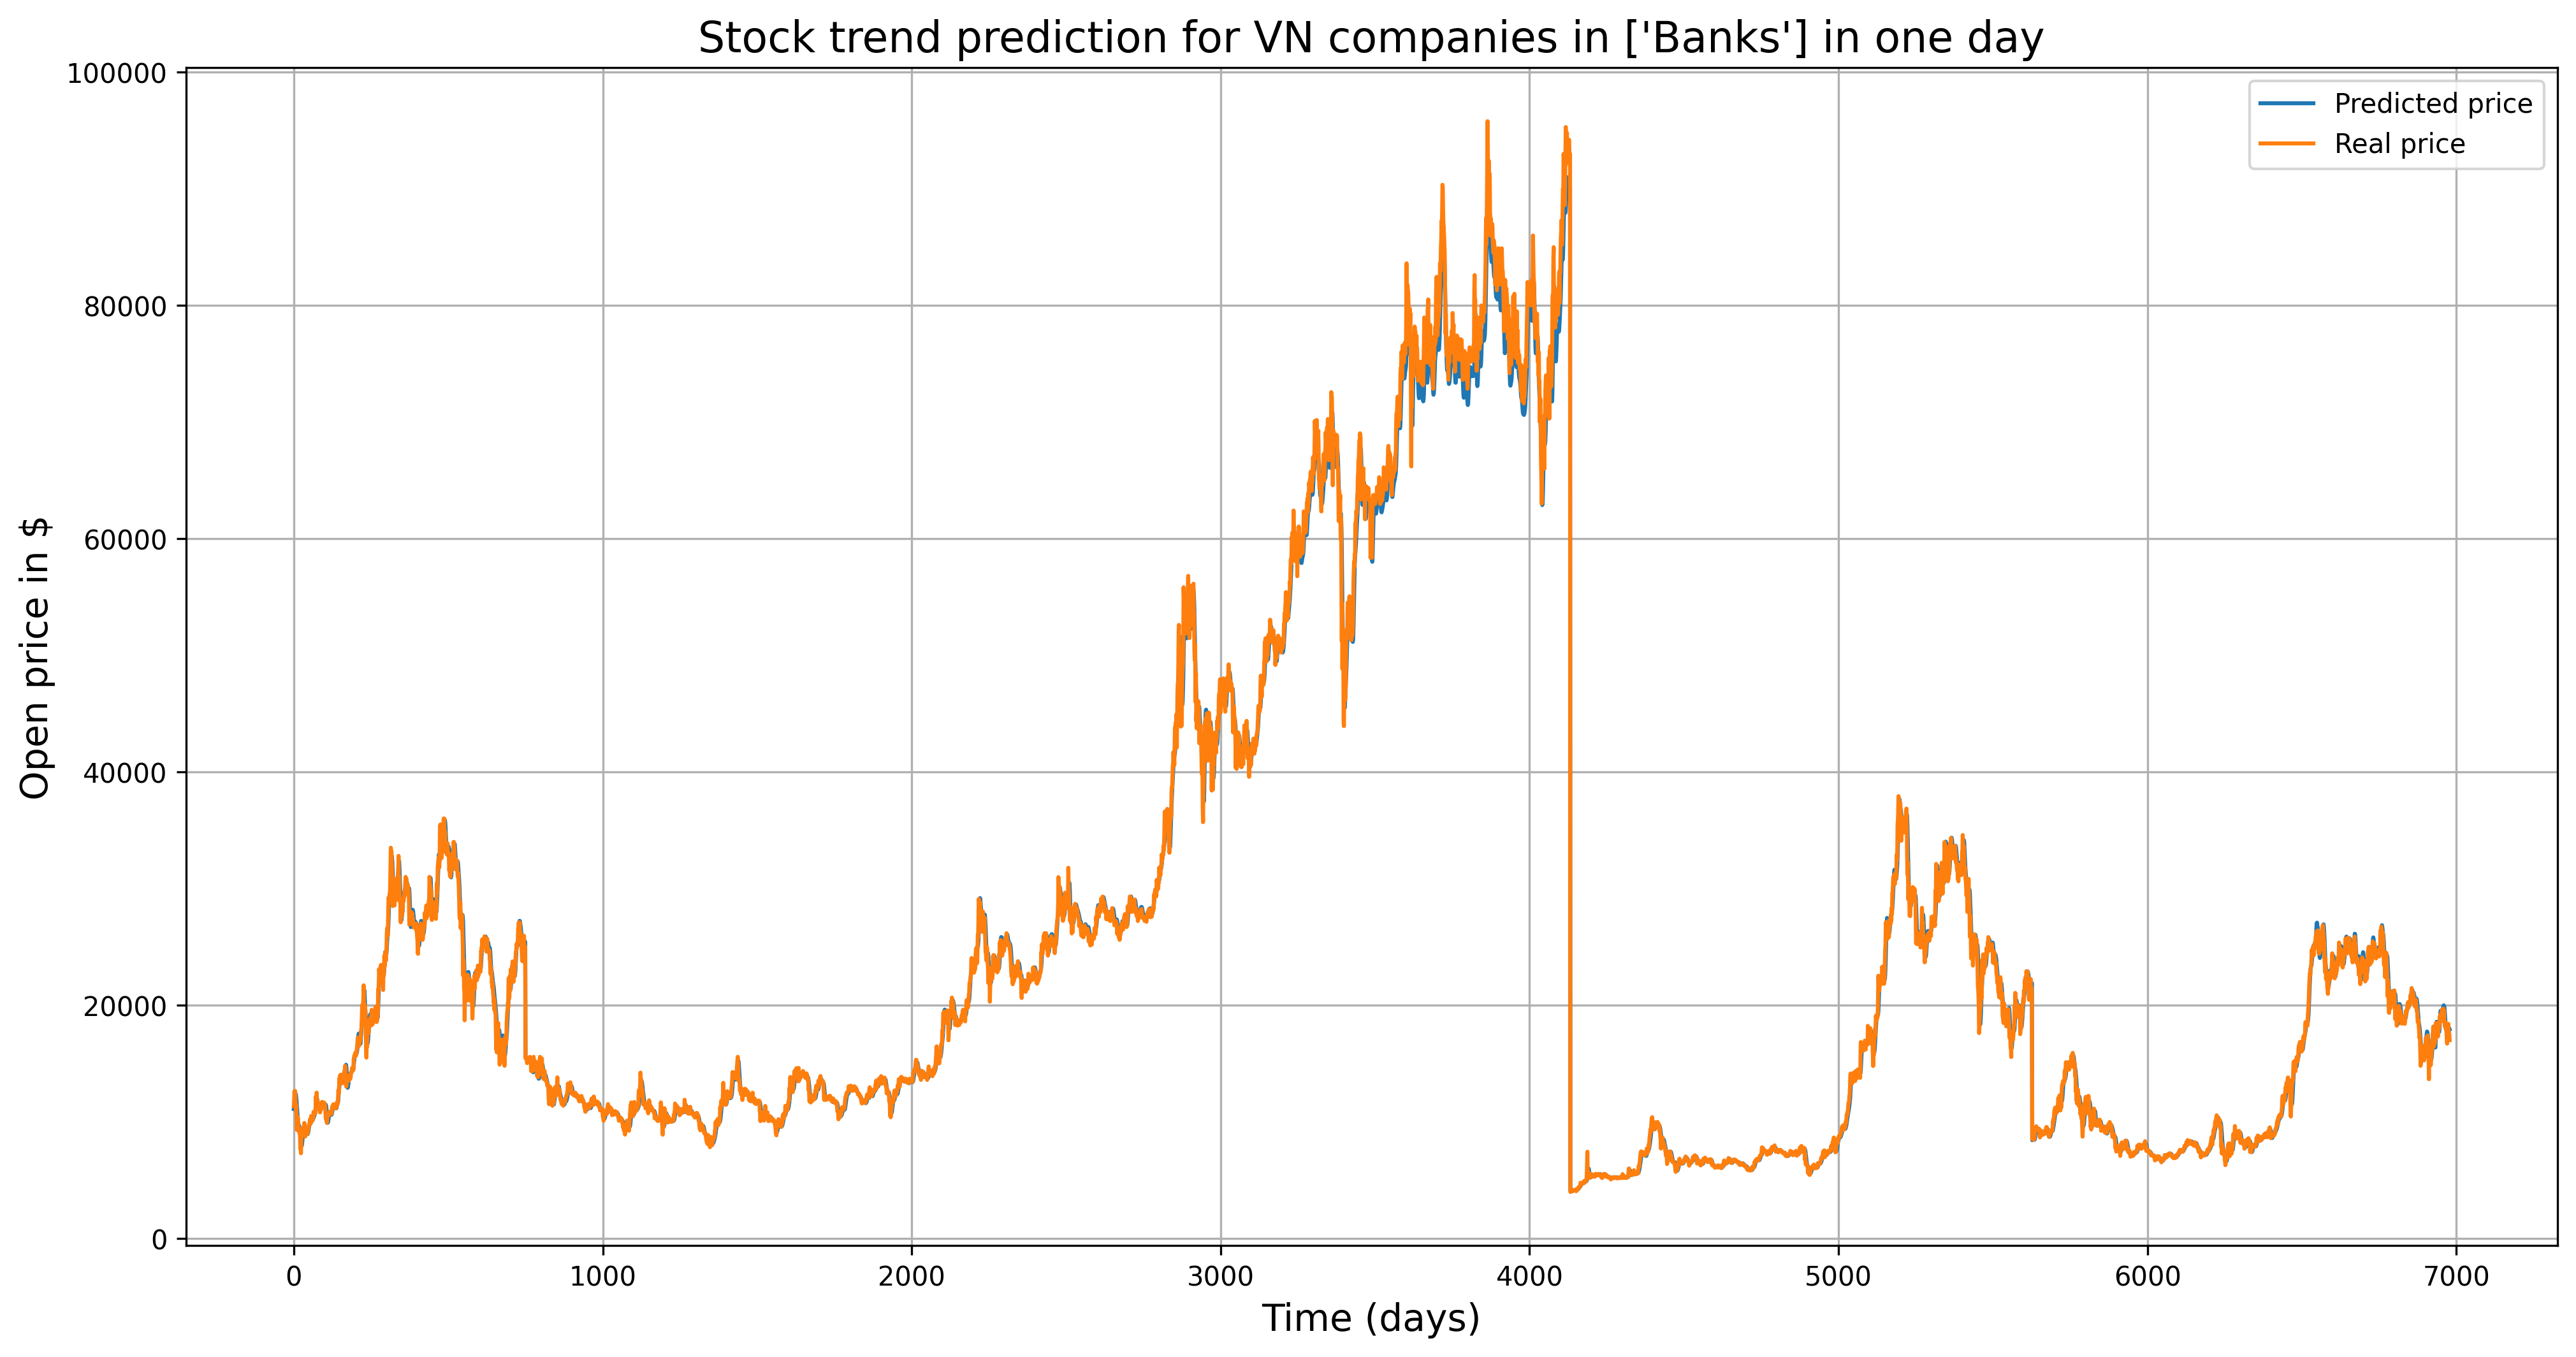

In [ ]:
y_pred = denorm(y_pred_norm, sc)
y_test = denorm(y_test_norm.reshape(-1, 1), sc)

# Visualize preditec stock price versus real stock price
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred, label='Predicted price')
plt.plot(y_test, label='Real price')
plt.title(f'Stock trend prediction for VN companies in {selected_industries} in one day', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid() # Add grid
plt.legend() # Add legend
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


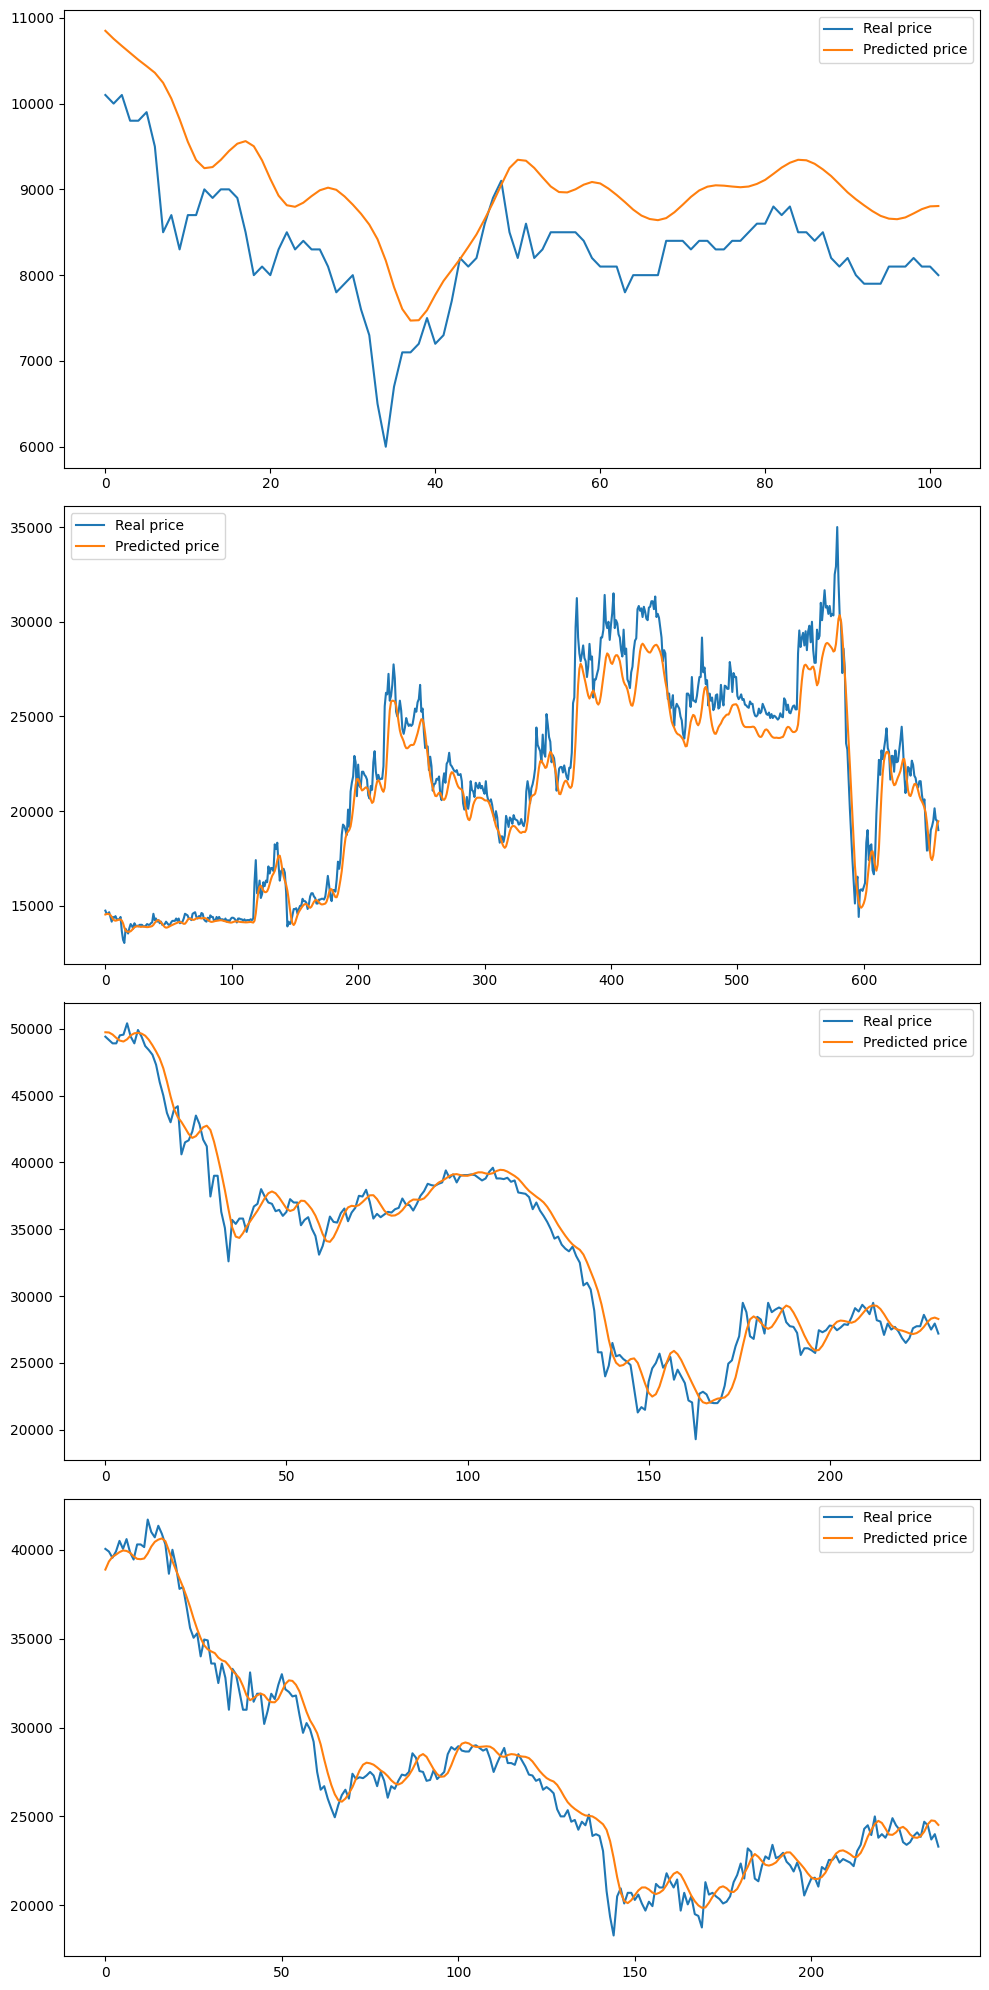

In [ ]:
#Test the model with unseen data

comp1 =  ['stock-historical-data/ABB-UpcomIndex-History.csv']
comp2 = ['stock-historical-data/EIB-VNINDEX-History.csv']
comp3 = ['stock-historical-data/TCB-VNINDEX-History.csv']
comp4 = ['stock-historical-data/TPB-VNINDEX-History.csv']


X_comp_1, y_comp_1 = prepare_input(comp1, window_size, k)
X_comp_1_train, X_comp_1_val, X_comp_1_test, y_comp_1_train, y_comp_1_val, y_comp_1_test, sc_1 = split(X_comp_1, y_comp_1)
X_comp_2 , y_comp_2 = prepare_input(comp2, window_size, k)
X_comp_2_train, X_comp_2_val, X_comp_2_test, y_comp_2_train, y_comp_2_val, y_comp_2_test, sc_2 = split(X_comp_2, y_comp_2)
X_comp_3 , y_comp_3 = prepare_input(comp3, window_size, k)
X_comp_3_train, X_comp_3_val, X_comp_3_test, y_comp_3_train, y_comp_3_val, y_comp_3_test, sc_3 = split(X_comp_3, y_comp_3)
X_comp_4 , y_comp_4 = prepare_input(comp4, window_size, k)
X_comp_4_train, X_comp_4_val, X_comp_4_test, y_comp_4_train, y_comp_4_val, y_comp_4_test, sc_4 = split(X_comp_4, y_comp_4)

y_pred_norm_1 = model_1.predict(X_comp_1_test)
y_pred_norm_2 = model_1.predict(X_comp_2_test)
y_pred_norm_3 = model_1.predict(X_comp_3_test)
y_pred_norm_4 = model_1.predict(X_comp_4_test)

y_pred_1 = denorm(y_pred_norm_1, sc_1)
y_pred_2 = denorm(y_pred_norm_2, sc_2)
y_pred_3 = denorm(y_pred_norm_3, sc_3)
y_pred_4 = denorm(y_pred_norm_4, sc_4)

y_test_1 = denorm(y_comp_1_test.reshape(-1, 1), sc_1)
y_test_2 = denorm(y_comp_2_test.reshape(-1, 1), sc_2)
y_test_3 = denorm(y_comp_3_test.reshape(-1, 1), sc_3)
y_test_4 = denorm(y_comp_4_test.reshape(-1, 1), sc_4)

#Visualize
y_pred = [y_pred_1, y_pred_2, y_pred_3, y_pred_4]
y_test = [y_test_1, y_test_2, y_test_3, y_test_4]

fig, axs = plt.subplots(4, 1, figsize=(10, 5 * 4))

for i in range(4):
  axs[i].plot(y_test[i], label='Real price')
  axs[i].plot(y_pred[i], label='Predicted price')
  #axs[i].set_title(f'Comparison for day {i+1}')
  axs[i].legend()

plt.tight_layout()
plt.show()


In [ ]:
upload_model_to_drive(model_1)

Model uploaded to: /content/drive/MyDrive/DL4AI /Models/VN/model_one_day.keras


In [ ]:
model = load_model_from_drive("model_one_day")

Model 'model_one_day' loaded successfully from /content/drive/MyDrive/DL4AI /Models/VN/model_one_day.keras


# Task 2.2: Predict for the next k days

In [ ]:
window_size = 60
k = 7

In [ ]:
X_1, y_1 = prepare_input(ticker_csv, window_size, k)
X_train_norm_1, X_val_norm_1, X_test_norm_1, y_train_norm_1, y_val_norm_1, y_test_norm_1, sc_1 = split(X_1, y_1)

In [ ]:
dir_name = "16 Banks"
upload_data_to_drive(X_train_norm_1, "X_train_norm_1", dir_name)
upload_data_to_drive(X_val_norm_1, "X_val_norm_1", dir_name)
upload_data_to_drive(X_test_norm_1, "X_test_norm_1", dir_name)
upload_data_to_drive(y_train_norm_1, "y_train_norm_1", dir_name)
upload_data_to_drive(y_val_norm_1, "y_val_norm_1", dir_name)
upload_data_to_drive(y_test_norm_1, "y_test_norm_1", dir_name)
upload_data_to_drive(sc_1, "sc_1", dir_name)

Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_train_norm_1.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_val_norm_1.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_test_norm_1.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_train_norm_1.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_val_norm_1.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_test_norm_1.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/sc_1.pkl


In [ ]:
dir_name = "16 Banks"
X_train_norm_1 = load_data_from_drive("X_train_norm_1.npy", dir_name)
X_val_norm_1 = load_data_from_drive("X_val_norm_1.npy", dir_name)
X_test_norm_1 = load_data_from_drive("X_test_norm_1.npy", dir_name)
y_train_norm_1 = load_data_from_drive("y_train_norm_1.npy", dir_name)
y_val_norm_1 = load_data_from_drive("y_val_norm_1.npy", dir_name)
y_test_norm_1 = load_data_from_drive("y_test_norm_1.npy", dir_name)
sc_1 = load_data_from_drive("sc_1.pkl", dir_name)

Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_train_norm_1.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_val_norm_1.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_test_norm_1.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_train_norm_1.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_val_norm_1.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_test_norm_1.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/sc_1.pkl


In [ ]:
#mcp = ModelCheckpoint(filepath='model_task2.weights.h5', monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=True)
model_k_ahead =LSTM_model_task2("model_kdays_ahead",(window_size, 5), 1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history1 = model_k_ahead.fit(X_train_norm_1, y_train_norm_1, shuffle=True, epochs=60, callbacks=[rlr], validation_data=(X_val_norm_1,y_val_norm_1), verbose=1, batch_size=1000)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 4.7176e-04 - val_mse: 4.7176e-04 - learning_rate: 1.0000e-04
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0012 - mse: 0.0012 - val_loss: 4.7053e-04 - val_mse: 4.7053e-04 - learning_rate: 1.0000e-04
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 4.6857e-04 - val_mse: 4.6857e-04 - learning_rate: 1.0000e-04
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 4.7651e-04 - val_mse: 4.7651e-04 - learning_rate: 1.0000e-04
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 4.8841e-04 - val_mse: 4.8841e-04 - learning_rate: 1.0000e-04
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 4.7070e-04 - val_mse: 4.7070e-04 - learning_rate: 1.0000e-04
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0013 - mse: 0.0013 - 

In [ ]:
# Get prediction on the test data
y_pred_norm_1 = model_k_ahead.predict(X_test_norm_1)
print("MSE on the test set: ", mean_squared_error(y_pred_norm_1, y_test_norm_1))
y_pred_1 = denorm(y_pred_norm_1, sc_1)
y_test_1 = denorm(y_test_norm_1, sc_1)

215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MSE on the test set:  0.0058931408498009204


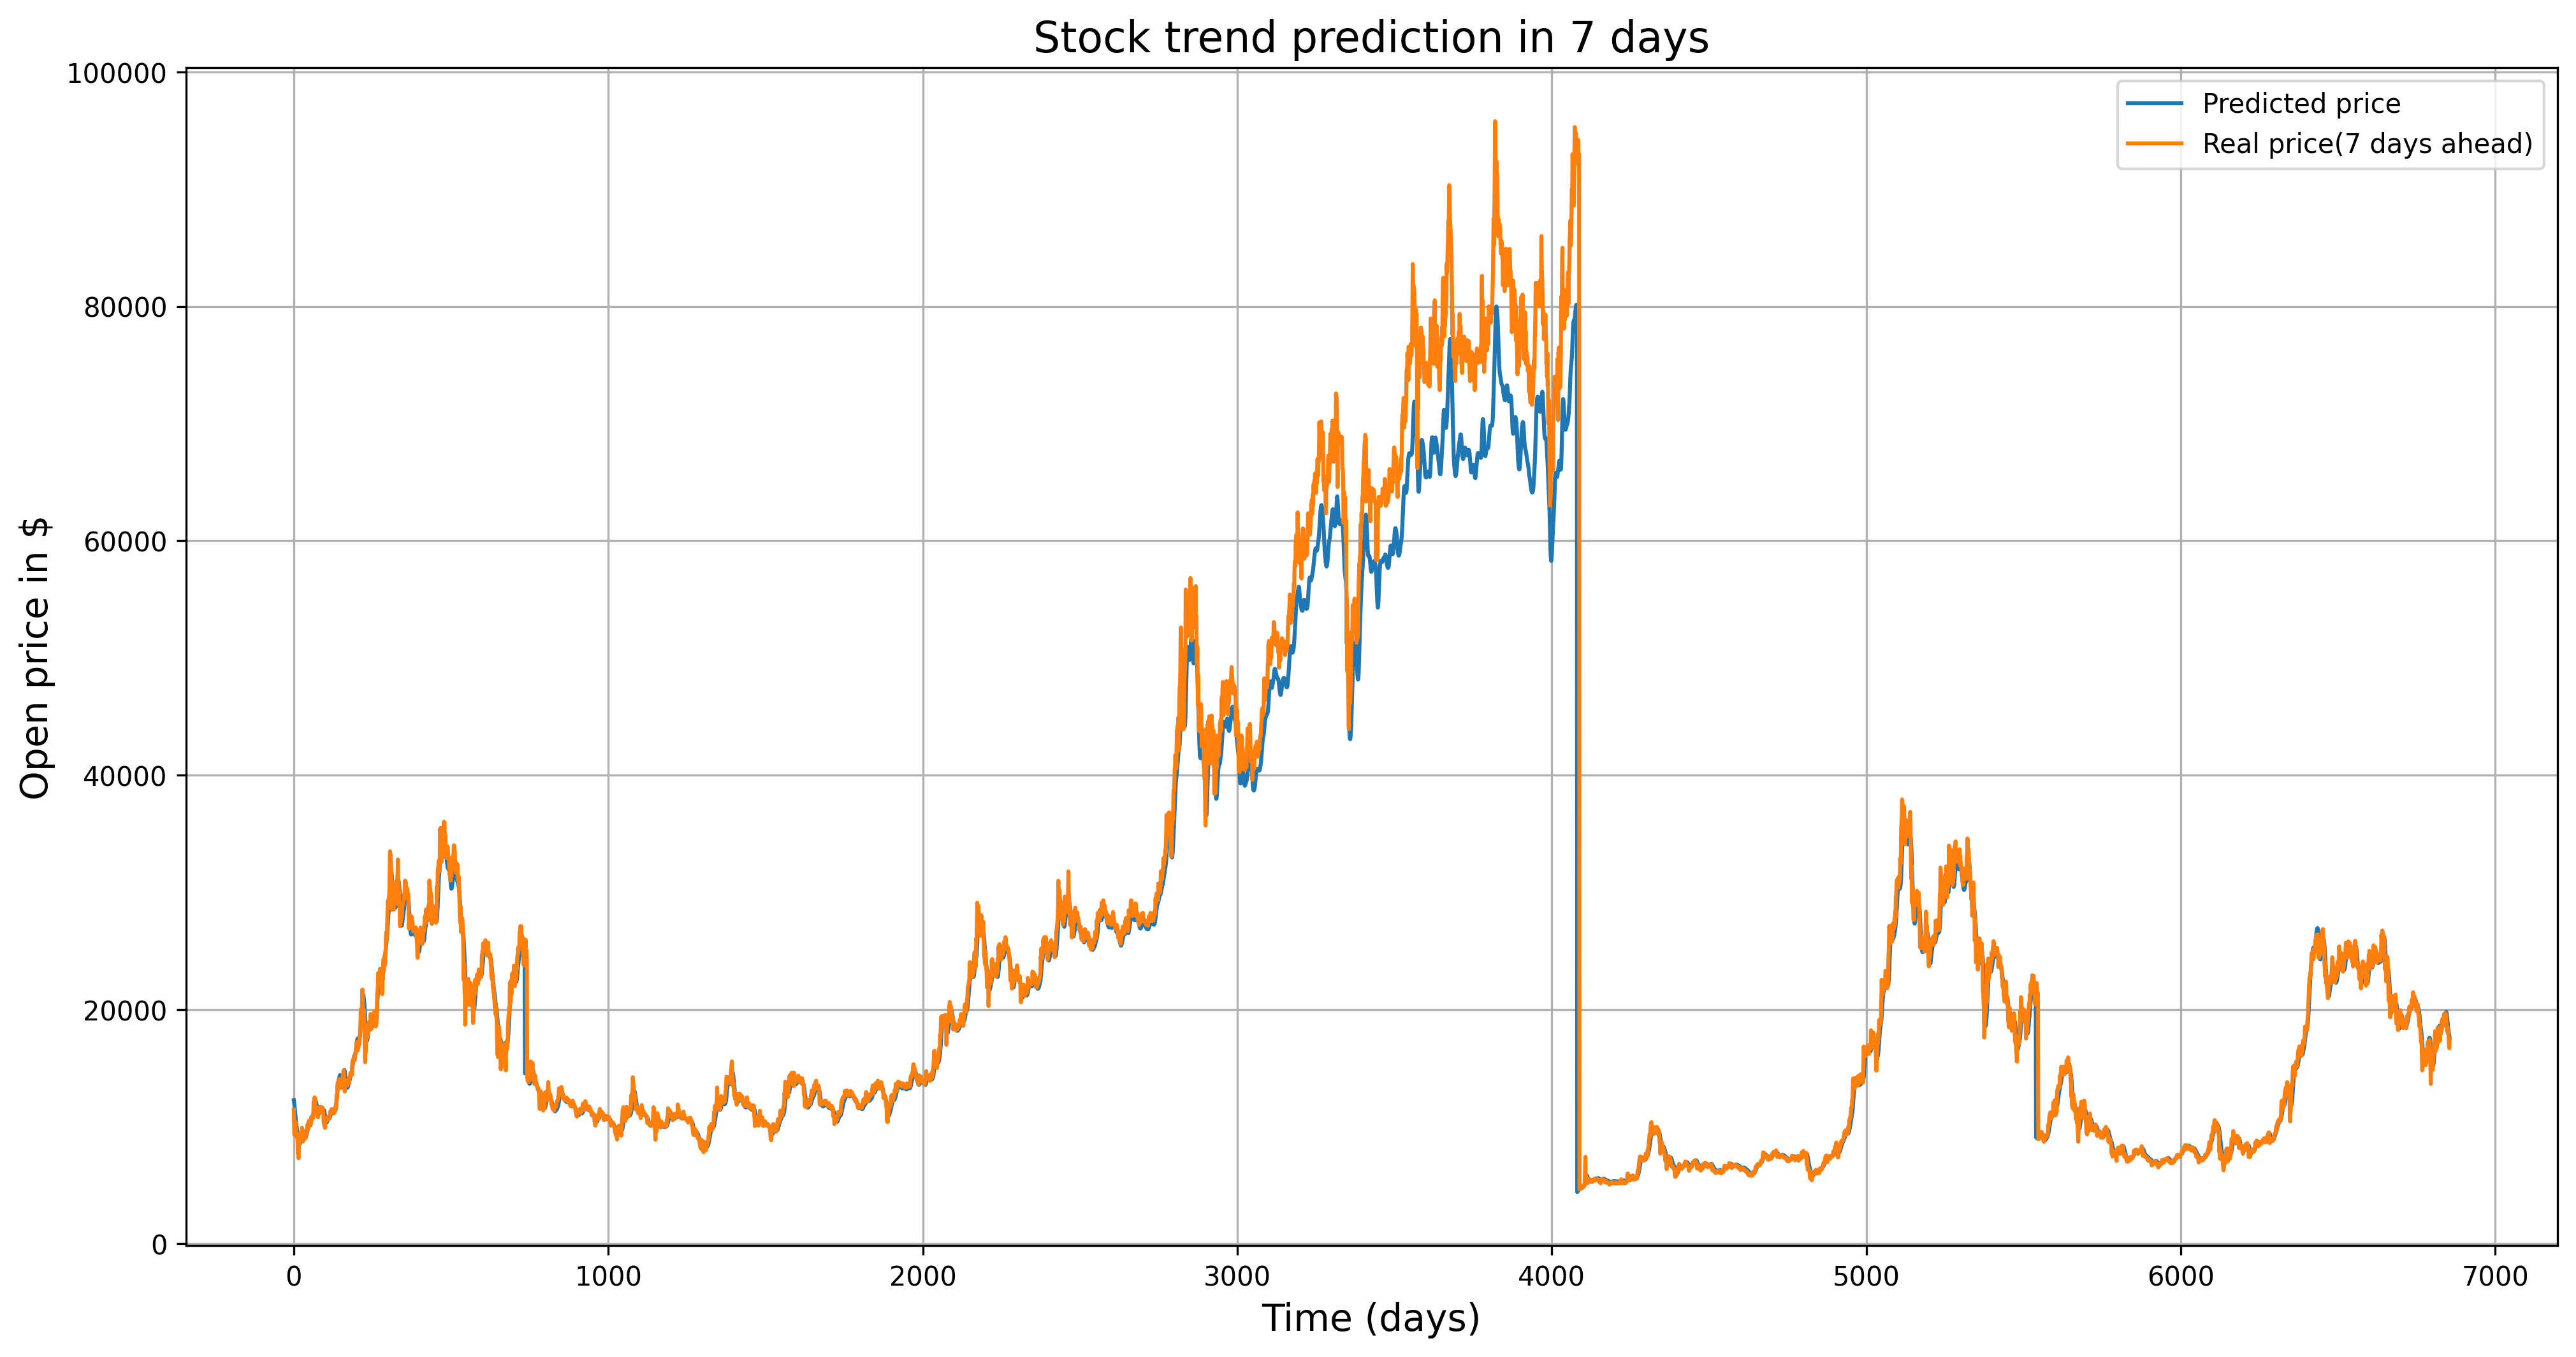

In [ ]:
# Visualize predited stock price versus real stock price
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_1[k:], label='Predicted price')
plt.plot(y_test_1[:-k], label=f'Real price({k} days ahead)')
plt.title(f'Stock trend prediction in {k} days', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid() # Add grid
plt.legend() # Add legend
plt.show()

In [ ]:
#save model
from tensorflow.keras.models import save_model
save_model(model_k_ahead, "model_k_ahead.keras")

In [ ]:
model_k_ahead = load_model_from_drive("model_kdays_ahead")

Model 'model_kdays_ahead' loaded successfully from /content/drive/MyDrive/DL4AI /Models/VN/model_kdays_ahead.keras


# Task 2.3: Predict for k consecutive days

In [ ]:
k = 15
window_size = 60
X_2, y_2 = prepare_input(ticker_csv, window_size, k, consecutive=True)
X_train_norm_2, X_val_norm_2, X_test_norm_2, y_train_norm_2, y_val_norm_2, y_test_norm_2, sc2 = split(X_2, y_2)

In [ ]:
y_2.shape

(34187, 15)

In [ ]:
np.isnan(X_train_norm_2).any()

False

In [ ]:
dir_name = "16 Banks"
upload_data_to_drive(X_train_norm_2, "X_train_norm_2", dir_name)
upload_data_to_drive(X_val_norm_2, "X_val_norm_2", dir_name)
upload_data_to_drive(X_test_norm_2, "X_test_norm_2", dir_name)
upload_data_to_drive(y_train_norm_2, "y_train_norm_2", dir_name)
upload_data_to_drive(y_val_norm_2, "y_val_norm_2", dir_name)
upload_data_to_drive(y_test_norm_2, "y_test_norm_2", dir_name)
upload_data_to_drive(sc2, "sc2", dir_name)

Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_train_norm_2.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_val_norm_2.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_test_norm_2.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_train_norm_2.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_val_norm_2.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_test_norm_2.npy
Data uploaded to: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/sc2.pkl


In [ ]:
dir_name = "16 Banks"  # Replace with your actual directory name

X_train_norm_2 = load_data_from_drive("X_train_norm_2.npy", dir_name)
X_val_norm_2 = load_data_from_drive("X_val_norm_2.npy", dir_name)
X_test_norm_2 = load_data_from_drive("X_test_norm_2.npy", dir_name)
y_train_norm_2 = load_data_from_drive("y_train_norm_2.npy", dir_name)
y_val_norm_2 = load_data_from_drive("y_val_norm_2.npy", dir_name)
y_test_norm_2 = load_data_from_drive("y_test_norm_2.npy", dir_name)
sc2 = load_data_from_drive("sc2.pkl", dir_name)

Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_train_norm_2.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_val_norm_2.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/X_test_norm_2.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_train_norm_2.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_val_norm_2.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/y_test_norm_2.npy
Data loaded from: /content/drive/MyDrive/DL4AI /Split datasets/16 Banks/sc2.pkl


In [ ]:
import tensorflow as tf

@tf.function
def exponential_decay_weighted_mse(y_pred, y_true, decay_rate=0.7):

    # Number of days in the sequence
    k = tf.shape(y_pred)[1]

    # Generate exponential weights
    weights = tf.pow(decay_rate, tf.range(k, dtype=tf.float32))
    weights = weights / tf.reduce_sum(weights)  # Normalize weights

    # Initialize total loss
     # This avoids the need for the loop and potential indexing issues
    weighted_loss = tf.reduce_mean(tf.square(y_pred - y_true) * weights[None, :], axis=0) # adding None to match shapes
    total_loss = tf.reduce_sum(weighted_loss)

    return total_loss

In [ ]:
model_k_consecutive =LSTM_model_task2("model_kdays_consecutive",(window_size, 5), k, loss = exponential_decay_weighted_mse)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#mcp = ModelCheckpoint(filepath='model_task2.weights.h5', monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=True)
history2 = model_k_consecutive.fit(X_train_norm_2, y_train_norm_2, shuffle=True, epochs=100, callbacks=[rlr], validation_data=(X_val_norm_2,y_val_norm_2), verbose=1, batch_size=1000)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0012 - mse: 0.0016 - val_loss: 2.5771e-04 - val_mse: 4.7892e-04 - learning_rate: 1.0000e-04
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0011 - mse: 0.0016 - val_loss: 2.5796e-04 - val_mse: 4.8177e-04 - learning_rate: 1.0000e-04
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0012 - mse: 0.0016 - val_loss: 2.5433e-04 - val_mse: 4.7904e-04 - learning_rate: 1.0000e-04
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0012 - mse: 0.0016 - val_loss: 2.5257e-04 - val_mse: 4.7749e-04 - learning_rate: 1.0000e-04
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0012 - mse: 0.0016 - val_loss: 2.5720e-04 - val_mse: 4.8209e-04 - learning_rate: 1.0000e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0012 - mse: 0.0016 - val_loss: 2.5256e-04 - val_mse: 4.7815e-04 - learning_rate: 1.0000e-04
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0012 - mse: 0.

In [ ]:
# Get prediction on the test data
y_pred_norm_2 = model_k_consecutive.predict(X_test_norm_2)
print("MSE on the test set: ", mean_squared_error(y_pred_norm_2, y_test_norm_2))
y_pred_2 = denorm(y_pred_norm_2, sc2)
y_test_2 = denorm(y_test_norm_2, sc2)

214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MSE on the test set:  0.0033425205944385005


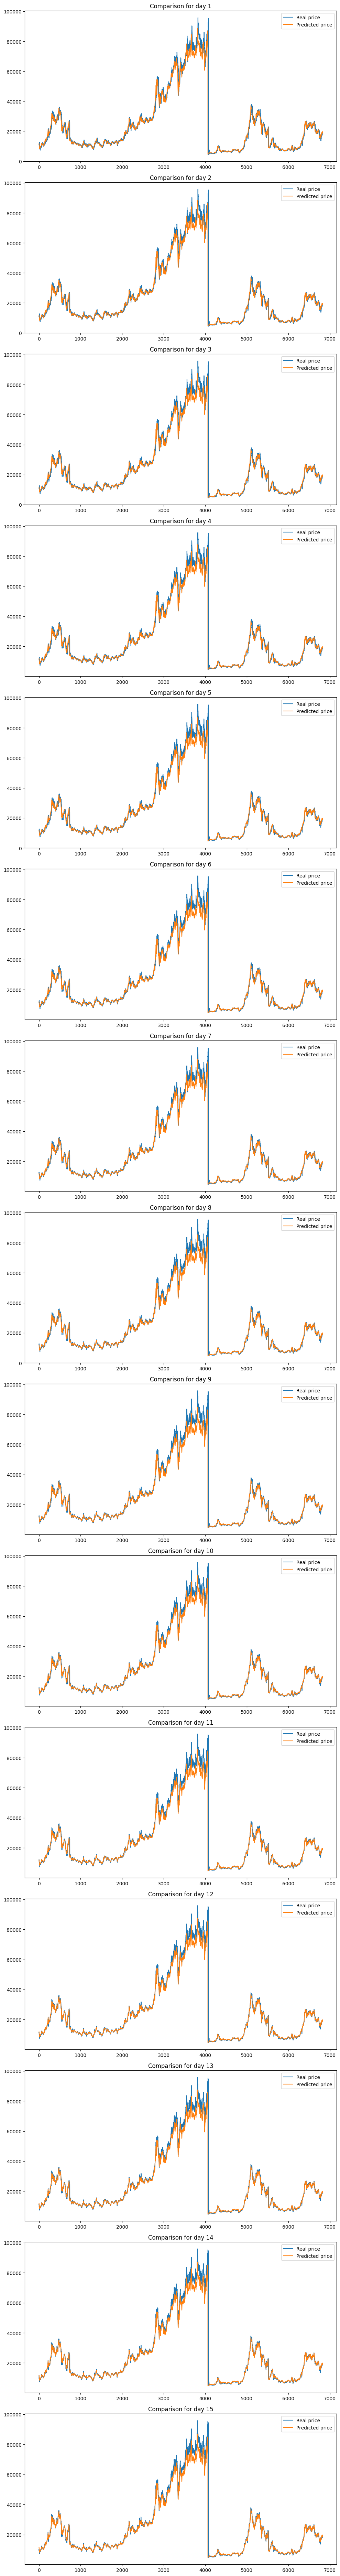

In [ ]:
y_test_2_t = y_test_2.transpose()
y_pred_2_t = y_pred_2.transpose()
k = y_test_2_t.shape[0]

fig, axs = plt.subplots(k, 1, figsize=(10, 5 * k))

for i in range(k):
  axs[i].plot(y_test_2_t[i][:-k], label='Real price')
  axs[i].plot(y_pred_2_t[i][k:], label='Predicted price')
  axs[i].set_title(f'Comparison for day {i+1}')
  axs[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
#save model
upload_model_to_drive(model_k_consecutive)

Model uploaded to: /content/drive/MyDrive/DL4AI /Models/VN/model_kdays_consecutive.keras


In [ ]:
model_k_consecutive = load_model_from_drive(
    "model_kdays_consecutive",
)
model_k_consecutive.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4), loss=exponential_decay_weighted_mse, metrics=['mse'])

Model 'model_kdays_consecutive' loaded successfully from /content/drive/MyDrive/DL4AI /Models/VN/model_kdays_consecutive.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


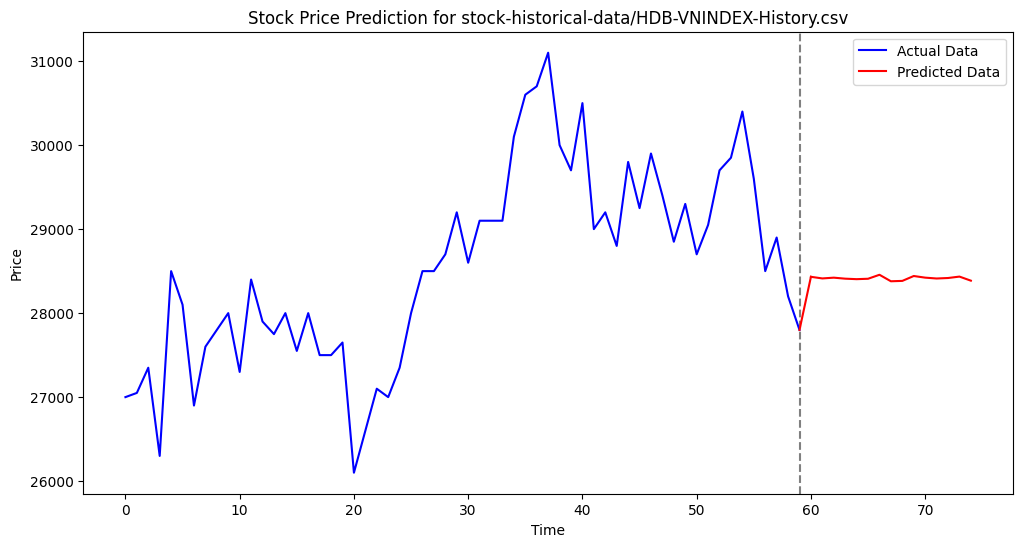

In [ ]:
# --- Data Loading and Preprocessing ---
path = "/content/drive/MyDrive/DL4AI /Data/data-vn-20230228"
window_size = 60
k = 30
comp1_df = pd.read_csv(os.path.join(path, ticker_csv[2]))
comp1_df.drop(['TradingDate', 'Unnamed: 0'], axis=1, inplace=True)
data = comp1_df.tail(window_size)

# Extract data for each feature
features =  ['Open', 'High', 'Low', 'Close', 'Volume']
data_values = [data[feature].values for feature in features]

# Normalize each feature using MinMaxScaler
scalers = [MinMaxScaler() for _ in features]
normalized_data = [scaler.fit_transform(np.array(values).reshape(-1, 1))
                   for scaler, values in zip(scalers, data_values)]

# Create X_data_norm by stacking the normalized features horizontally
X_data_norm = np.hstack(normalized_data)


# --- Prediction and Visualization ---
y_pred_norm = model_k_consecutive.predict(X_data_norm.reshape(1, 60, 5))  # Predict for the last window
y_pred = denorm(y_pred_norm, scalers[0])  # Assuming you have the denorm function

# Append predicted values to original data for visualization
actual_data = data['Open'].values  # Get the last window_size days of actual data
all_data = np.concatenate((actual_data, y_pred.flatten()))

# Create x-axis values for plotting
x_axis = np.arange(len(all_data))


# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(x_axis[:len(actual_data)], actual_data, color='blue', label='Actual Data')
plt.plot(x_axis[len(actual_data):], y_pred.flatten(), color='red', label='Predicted Data')
plt.axvline(x=len(actual_data) - 1, color='gray', linestyle='--')

# Connect actual and predicted data with a line segment
plt.plot([x_axis[len(actual_data) - 1], x_axis[len(actual_data)]],
         [actual_data[-1], y_pred.flatten()[0]],
         color='red') # New line

plt.title(f'Stock Price Prediction for {ticker_csv[4]}')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
y_pred

array([[28432.227, 28413.033, 28422.094, 28410.137, 28404.312, 28409.092,
        28456.533, 28379.184, 28383.67 , 28441.832, 28422.332, 28412.229,
        28417.973, 28434.855, 28386.314]], dtype=float32)

# BUY/SELL SIGNAL

In this task, I encode the buying/selling signal for each sample based on whether the Open price is below or above the specified percentile of the data within a window frame of 30 days

In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=71acdc66041c38dcfaac6aaaa6b457aebe38cf28de896e1e572f192066d4d7f7
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta


In [ ]:
import pandas as pd
import numpy as np
from ta.trend import SMAIndicator  # Import SMAIndicator from ta

from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands

def generate_signals(ticker_data, window_frame):
    # Ensure 'Open' is numeric and clean data
    ticker_data['Open'] = pd.to_numeric(ticker_data['Open'], errors='coerce')
    ticker_data = ticker_data.dropna(subset=['Open'])
    ticker_data = ticker_data[ticker_data['Open'] != 0]

    # Calculate SMA
    sma_window = int(len(ticker_data) / 15)
    sma_indicator = SMAIndicator(close=ticker_data['Open'], window=sma_window, fillna=True)
    ticker_data['SMA'] = sma_indicator.sma_indicator()

    # Calculate RSI
    rsi_indicator = RSIIndicator(close=ticker_data['Open'], window=14, fillna=True)
    ticker_data['RSI'] = rsi_indicator.rsi()

    # Calculate MACD
    macd_indicator = MACD(close=ticker_data['Open'], fillna=True)
    ticker_data['MACD'] = macd_indicator.macd()
    ticker_data['MACD_Signal'] = macd_indicator.macd_signal()

    # Initialize signals
    ticker_data['buy'] = 0.0
    ticker_data['sell'] = 0.0

    # Generate buy/sell signals based on relaxed conditions
    for i in range(len(ticker_data)):
        # Define rolling window for percentile calculations
        if i + window_frame <= len(ticker_data):
            window = ticker_data['Open'].iloc[i:i + window_frame].values
        else:
            window = ticker_data['Open'].iloc[i:].values

        # Compute percentiles and thresholds
        low_threshold, high_threshold = np.percentile(window, [20, 80])
        current_price = ticker_data['Open'].iloc[i]
        max_profit = (np.max(window) - current_price) / np.max(window)
        max_loss = (current_price - np.min(window)) / current_price

        # Relaxed Buy Signal
        if (
            current_price <= low_threshold * 1.05 and  # Relax the threshold a bit (e.g., 5% above low)
            max_profit >= 0.15 or
            current_price < ticker_data['SMA'].iloc[i] and ticker_data['RSI'].iloc[i] < 50 and
            ticker_data['MACD'].iloc[i] >= ticker_data['MACD_Signal'].iloc[i]
        ):
            ticker_data.at[i, 'buy'] = 1  # Buy signal

        # Relaxed Sell Signal
        if (
            current_price >= high_threshold * 0.95 and  # Relax the threshold a bit (e.g., 5% below high)
            max_loss >= 0.15 or
            current_price > ticker_data['SMA'].iloc[i] and ticker_data['RSI'].iloc[i] > 50 and
            ticker_data['MACD'].iloc[i] <= ticker_data['MACD_Signal'].iloc[i]
        ):
            ticker_data.at[i, 'sell'] = 1  # Sell signal

    return ticker_data[['TradingDate','Open', 'SMA', 'RSI', 'MACD', 'MACD_Signal', 'buy', 'sell']]




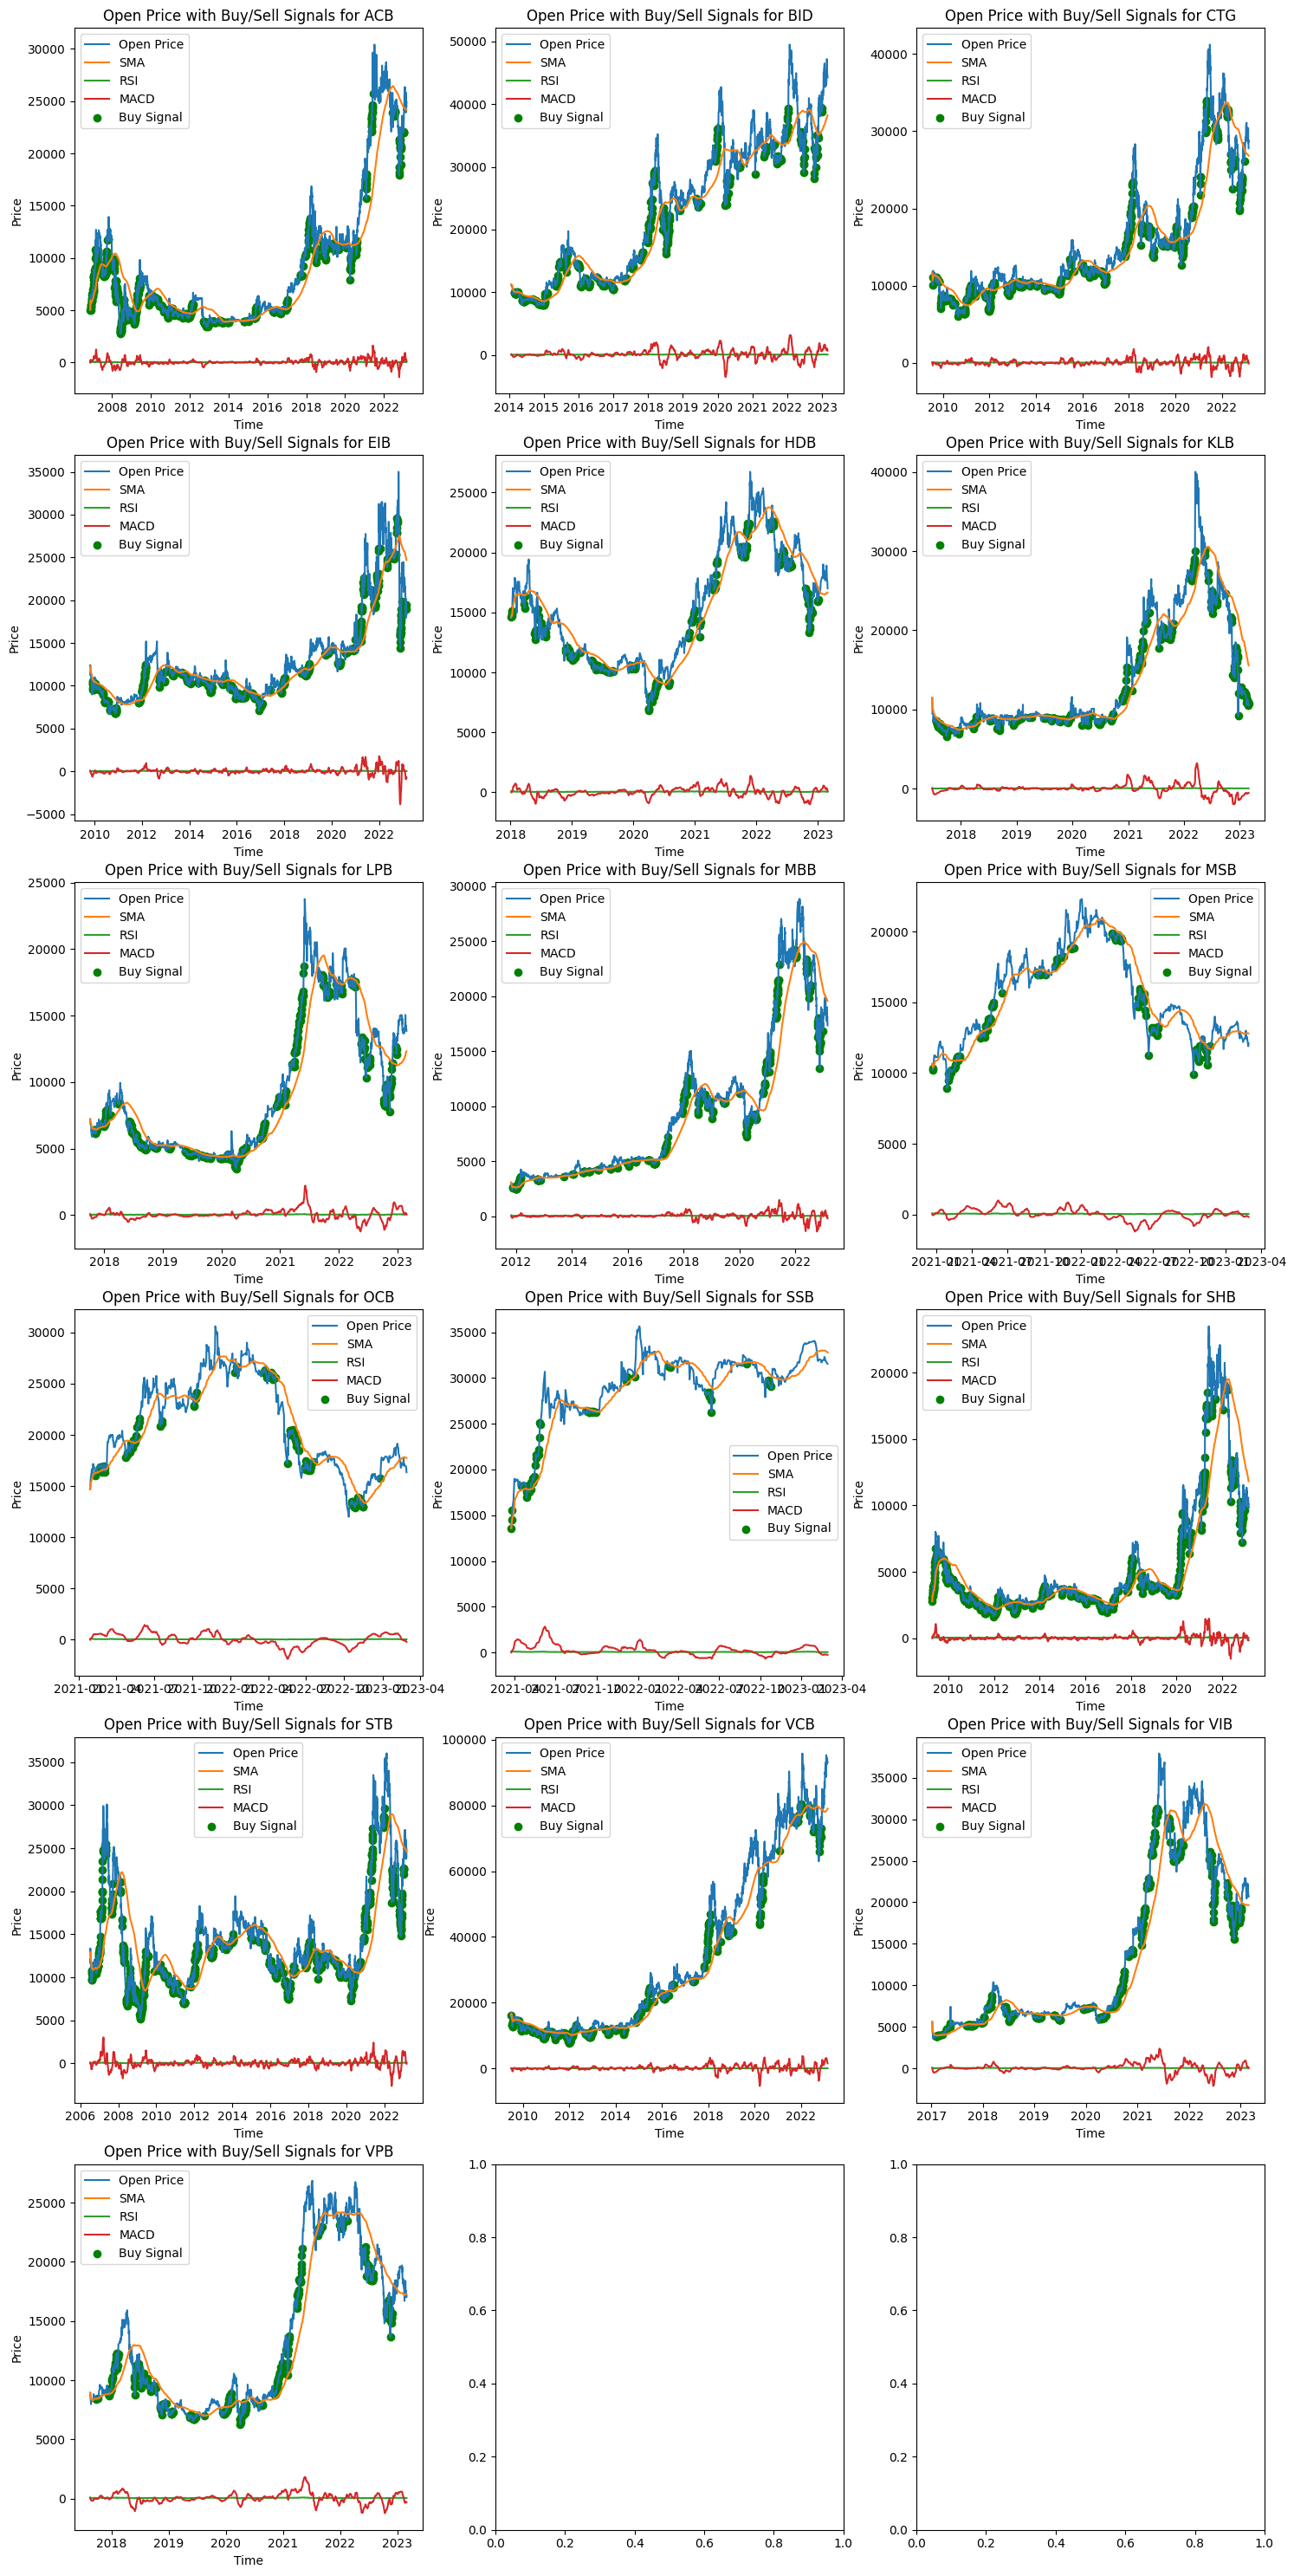

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/DL4AI /Data/data-vn-20230228"

# Calculate the number of rows and columns for subplots
num_companies = len(ticker_csv)
num_cols = 3  # Adjust as needed
num_rows = (num_companies + num_cols - 1) // num_cols  # Calculate rows dynamically

# Create subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.tight_layout(pad=3.0)  # Adjust padding for better spacing

# Iterate through companies and plot on subplots
for i, ticker in enumerate(ticker_csv):
    comp_name = ticker.split('/')[1].split('-')[0]
    comp_df = pd.read_csv(os.path.join(path, ticker))
     # --- Convert TradingDate to datetime ---
    comp_df['TradingDate'] = pd.to_datetime(comp_df['TradingDate'])
    test_buy_sell = generate_signals(comp_df, 20)

    # --- Set TradingDate as index ---
    test_buy_sell = test_buy_sell.set_index('TradingDate')

    # Get the correct subplot axes
    row = i // num_cols
    col = i % num_cols
    ax = axs[row, col] if num_rows > 1 else axs[col]  # Handle single row case

    # Plot on the subplot
    ax.plot(test_buy_sell.index, test_buy_sell['Open'], label='Open Price')
    ax.plot(test_buy_sell.index, test_buy_sell['SMA'], label='SMA')
    ax.plot(test_buy_sell.index, test_buy_sell['RSI'], label='RSI')
    ax.plot(test_buy_sell.index, test_buy_sell['MACD'], label='MACD')
    ax.scatter(test_buy_sell.index[test_buy_sell['buy'] == 1],
               test_buy_sell['Open'][test_buy_sell['buy'] == 1],
               color='green', label='Buy Signal')
    ax.scatter(test_buy_sell.index[test_buy_sell['sell'] == 1],
               test_buy_sell['Open'][test_buy_sell['sell'] == 1],
               color='red', label='Sell Signal')
    ax.set_title(f'Open Price with Buy/Sell Signals for {comp_name}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Price')
    ax.legend()

plt.show()

In [ ]:
ticker_fe = ticker_csv.copy()

for i in range(len(ticker_csv)):
  ticker = ticker_csv[i]
  df  = pd.read_csv(os.path.join(path, ticker))

  df_fe = generate_signals(df, 20)  # Updated to df after calculating indicators
  df_fe['MACD_abs_mean'] = abs(df_fe.loc[:, 'MACD']).mean()
  ticker_fe[i] = df_fe

In [ ]:
X_data, y_buy, y_sell = [], [], []
look_back_days = 20

for ticker in ticker_fe:
    for i in range(look_back_days, len(ticker)):
        window = ticker['Open'].iloc[i - look_back_days : i]

        # Get MACD value for the current day
        macd_value = ticker['MACD'].iloc[i]
        macd_threshold = ticker['MACD_abs_mean'].iloc[i]

        # Filter based on MACD condition
        if abs(macd_value) > macd_threshold:
            X_data.append(window)
            y_buy.append(ticker['buy'].iloc[i])
            y_sell.append(ticker['sell'].iloc[i])


In [ ]:
X_data = np.array(X_data).reshape(-1, 20, 1)
y_buy = np.array(y_buy).reshape(-1, 1)
y_sell = np.array(y_sell).reshape(-1, 1)
X_data.shape, y_buy.shape, y_sell.shape

((11333, 20, 1), (11333, 1), (11333, 1))

In [ ]:
y_buy.sum()

2478.0

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Split data into train/test sets for 'buy'
X_train_buy, X_test_buy, y_train_buy, y_test_buy = train_test_split(X_data, y_buy, test_size=0.2, shuffle=False)
X_train_buy, X_val_buy, y_train_buy, y_val_buy = train_test_split(X_train_buy, y_train_buy, test_size=0.2, shuffle=False)

# Split data into train/test sets for 'sell'
X_train_sell, X_test_sell, y_train_sell, y_test_sell = train_test_split(X_data, y_sell, test_size=0.2, shuffle=False)
X_train_sell, X_val_sell, y_train_sell, y_val_sell = train_test_split(X_train_sell, y_train_sell, test_size=0.2, shuffle=False)

#Normalize
scaler = MinMaxScaler()
X_train_norm_buy = scaler.fit_transform(X_train_buy.reshape(-1, 1))
X_val_norm_buy = scaler.transform(X_val_buy.reshape(-1, 1))
X_test_norm_buy = scaler.transform(X_test_buy.reshape(-1, 1))

X_train_norm_sell = scaler.fit_transform(X_train_sell.reshape(-1, 1))
X_val_norm_sell = scaler.transform(X_val_sell.reshape(-1, 1))
X_test_norm_sell = scaler.transform(X_test_sell.reshape(-1, 1))

#Reshape
X_train_norm_buy = X_train_norm_buy.reshape(-1, 20, 1)
X_val_norm_buy = X_val_norm_buy.reshape(-1, 20, 1)
X_test_norm_buy = X_test_norm_buy.reshape(-1, 20, 1)

X_train_norm_sell = X_train_norm_sell.reshape(-1, 20, 1)
X_val_norm_sell = X_val_norm_sell.reshape(-1, 20, 1)
X_test_norm_sell = X_test_norm_sell.reshape(-1, 20, 1)


In [ ]:
# For model_buy

model_buy = LSTM_model_task3("model_buy", (20, 1), 1, activation='sigmoid',
                        metrics=['accuracy', 'precision'],  # Add binary classification metrics
                        loss=['binary_crossentropy'])  # Use binary cross-entropy loss

# For model_sell (similarly)
model_sell = LSTM_model_task3("model_sell", (20, 1), 1, activation='sigmoid',
                        metrics=['accuracy', 'precision'],
                        loss=['binary_crossentropy'])

from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
%time
es = es = EarlyStopping(monitor='precision', mode='min', verbose=1, patience=5)
rlr = ReduceLROnPlateau(monitor='precision', mode='min', verbose = 0,
                               factor = 0.2, patience = 5, min_lr = 0.0001)

CPU times: user 0 ns, sys: 3 µs, total: 3 µs
Wall time: 6.68 µs


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Model for buying signal

In [ ]:
model_buy.summary()

Model: "model_buy"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                       │ (None, 20, 32)              │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 20, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_29 (LSTM)                       │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 10)                  │             330 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,141 (51.33 KB)

 Trainable params: 13,077 (51.08 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
history = model_buy.fit(X_train_norm_buy, y_train_buy, shuffle=True, epochs=15, validation_data=(X_val_norm_buy,y_val_buy), callbacks = [es, rlr], verbose=1, batch_size=100)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6359 - loss: 0.5920 - precision: 0.2922 - val_accuracy: 0.6163 - val_loss: 0.6307 - val_precision: 0.3628 - learning_rate: 1.0000e-06
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6295 - loss: 0.5931 - precision: 0.2937 - val_accuracy: 0.6163 - val_loss: 0.6280 - val_precision: 0.3596 - learning_rate: 1.0000e-06
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6316 - loss: 0.5922 - precision: 0.2911 - val_accuracy: 0.6196 - val_loss: 0.6256 - val_precision: 0.3608 - learning_rate: 1.0000e-06
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6340 - loss: 0.5935 - precision: 0.2966 - val_accuracy: 0.6246 - val_loss: 0.6232 - val_precision: 0.3634 - learning_rate: 1.0000e-06
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6385 - loss: 0.5823 - precision: 0.2896 - val_accuracy: 0.6262 - val_loss: 0.6210 - val_precision: 0.3610 - learning_rate: 1.0000e-06
Epoch 5:

In [ ]:
test_loss = model_buy.evaluate(X_test_norm_buy, y_test_buy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7813 - loss: 0.4550 - precision: 0.1312


In [ ]:
y_pred = model_buy.predict(X_test_norm_buy)
y_pred_binary = (y_pred > y_pred.mean()).astype(int)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


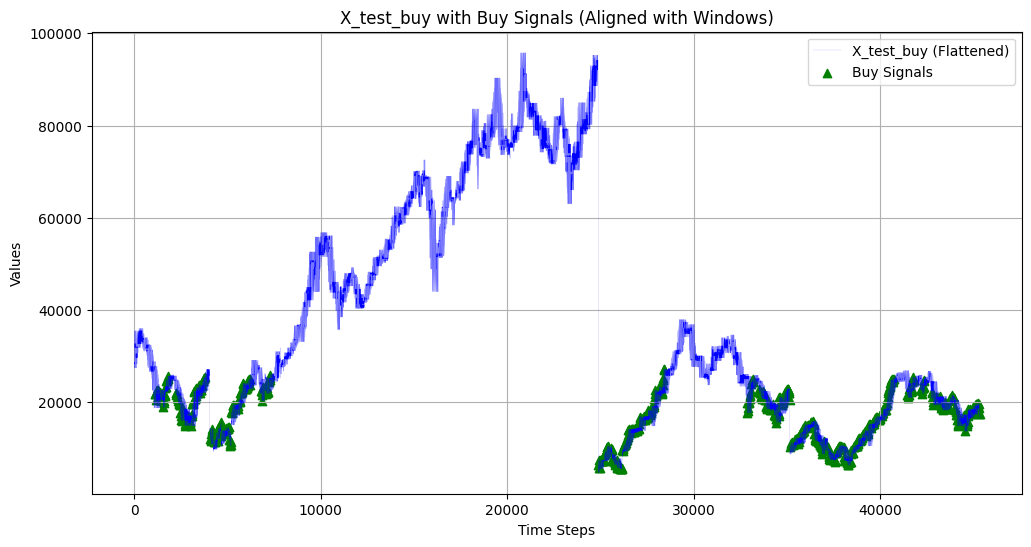

In [ ]:
k = 20  # Window size (look-back days)

# Initialize an array for padded buy signals
y_pred_padded = np.zeros((len(y_pred_binary), k))

# Pad each buy signal with zeros in front to match the window size
for i in range(len(y_pred_binary)):
    y_pred_padded[i, :] = np.pad(y_pred_binary[i], (k - 1, 0), mode='constant')

# Flatten X_test_buy for visualization
X_test_buy_flattened = X_test_buy.flatten()

# Flatten the padded buy signals for alignment with the X_test_buy timeline
y_pred_padded_flattened = y_pred_padded.flatten()

# Identify indices where buy signals are present (value = 1)
buy_signal_indices = np.where(y_pred_padded_flattened == 1)[0]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(X_test_buy_flattened, label='X_test_buy (Flattened)', linewidth=0.07, color='blue')  # Plot the test data

# Overlay the buy signals
plt.scatter(
    buy_signal_indices,
    X_test_buy_flattened[buy_signal_indices],
    color='green',
    marker='^',
    label='Buy Signals'
)

# Add labels, title, legend, and grid
plt.title('X_test_buy with Buy Signals (Aligned with Windows)')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Save model
upload_model_to_drive(model_buy)

Model uploaded to: /content/drive/MyDrive/DL4AI /Models/VN/model_buy.keras


## Model for selling signal

In [ ]:
history = model_sell.fit(X_train_norm_sell, y_train_sell, shuffle=True, epochs=15, callbacks=[es, rlr], validation_data=(X_val_norm_sell,y_val_sell), verbose=1, batch_size=1000)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5171 - loss: 0.7103 - precision: 0.3246 - val_accuracy: 0.3738 - val_loss: 0.6950 - val_precision: 0.3227 - learning_rate: 1.0000e-06
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5221 - loss: 0.7092 - precision: 0.3248 - val_accuracy: 0.4035 - val_loss: 0.6948 - val_precision: 0.3303 - learning_rate: 1.0000e-06
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5180 - loss: 0.7091 - precision: 0.3219 - val_accuracy: 0.4179 - val_loss: 0.6946 - val_precision: 0.3264 - learning_rate: 1.0000e-06
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5244 - loss: 0.7082 - precision: 0.3238 - val_accuracy: 0.4361 - val_loss: 0.6944 - val_precision: 0.3264 - learning_rate: 1.0000e-06
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5298 - loss: 0.7059 - precision: 0.3307 - val_accuracy: 0.4564 - val_loss: 0.6942 - val_precision: 0.3254 - learning_rate: 1.0000e-06
Epoch 5: early 

In [ ]:
test_loss = model_sell.evaluate(X_test_norm_sell, y_test_sell)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3285 - loss: 0.7056 - precision: 0.3021


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


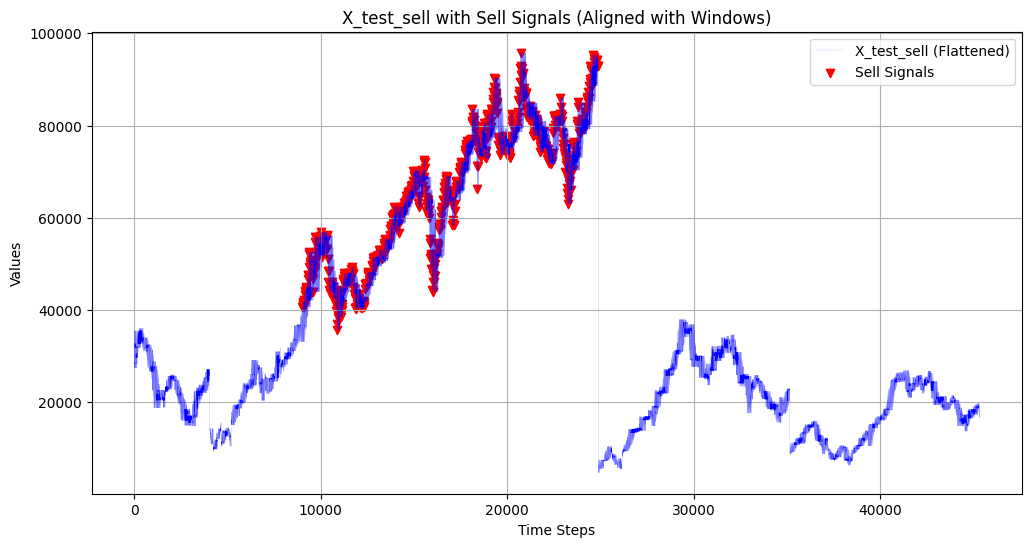

In [ ]:
y_pred = model_sell.predict(X_test_norm_sell)
y_pred_binary = (y_pred > y_pred.mean()).astype(int)

k = 20  # Window size (look-back days)

# Initialize an array for padded buy signals
y_pred_padded = np.zeros((len(y_pred_binary), k))

# Pad each buy signal with zeros in front to match the window size
for i in range(len(y_pred_binary)):
    y_pred_padded[i, :] = np.pad(y_pred_binary[i], (k - 1, 0), mode='constant')

# Flatten the padded buy signals for alignment with the X_test_buy timeline
y_pred_padded_flattened = y_pred_padded.flatten()

# Identify indices where buy signals are present (value = 1)
buy_signal_indices = np.where(y_pred_padded_flattened == 1)[0]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(X_test_sell.flatten(), label='X_test_sell (Flattened)', linewidth=0.07, color='blue')  # Plot the test data

# Overlay the buy signals
plt.scatter(
    buy_signal_indices,
    X_test_buy_flattened[buy_signal_indices],
    color='red',
    marker='v',
    label='Sell Signals'
)

# Add labels, title, legend, and grid
plt.title('X_test_sell with Sell Signals (Aligned with Windows)')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
upload_model_to_drive(model_sell)

Model uploaded to: /content/drive/MyDrive/DL4AI /Models/VN/model_sell.keras


In [ ]:
model_buy_0 = load_model_from_drive("model_buy")

Model 'model_buy' loaded successfully from /content/drive/MyDrive/DL4AI /Models/VN/model_buy.keras


In [ ]:
history = model_sell.fit(X_train_norm_sell, y_train_sell, shuffle=True, epochs=15, callbacks=[rlr], validation_data=(X_val_norm_sell,y_val_sell), verbose=1, batch_size=1000)

Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 4.3776e-04 - mse: 4.3776e-04 - val_loss: 3.1538e-04 - val_mse: 3.1538e-04 - learning_rate: 1.0000e-04
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.6918e-04 - mse: 3.6918e-04 - val_loss: 3.1473e-04 - val_mse: 3.1473e-04 - learning_rate: 1.0000e-04
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 3.6283e-04 - mse: 3.6283e-04 - val_loss: 3.1488e-04 - val_mse: 3.1488e-04 - learning_rate: 1.0000e-04
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.6251e-04 - mse: 3.6251e-04 - val_loss: 3.1647e-04 - val_mse: 3.1647e-04 - learning_rate: 1.0000e-04
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.5796e-04 - mse: 3.5796e-04 - val_loss: 3.1796e-04 - val_mse: 3.1796e-04 - learning_rate: 1.0000e-04
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 3.6104e-04 - mse: 3.6104e-04 - val_loss: 3.1687e-04 - val_mse: 3.1687e-04 - learning_rate: 1.0000e-04
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━

In [ ]:
upload_model_to_drive(model_sell)

Model uploaded to: /content/drive/MyDrive/DL4AI /Models/VN/model_sell.keras


In [ ]:
model_sell_0 = load_model_from_drive("model_sell")

Model 'model_sell' loaded successfully from /content/drive/MyDrive/DL4AI /Models/VN/model_sell.keras


# Task 4: Porfolio Composition

In [ ]:
#For banks only
with open("/content/drive/MyDrive/DL4AI /Split datasets/16 Banks/ticker_list.txt", "r") as f:
  banks_csv = f.read().splitlines()

In [ ]:
banks_csv

['stock-historical-data/ACB-VNINDEX-History.csv',
 'stock-historical-data/BID-VNINDEX-History.csv',
 'stock-historical-data/CTG-VNINDEX-History.csv',
 'stock-historical-data/EIB-VNINDEX-History.csv',
 'stock-historical-data/HDB-VNINDEX-History.csv',
 'stock-historical-data/KLB-UpcomIndex-History.csv',
 'stock-historical-data/LPB-VNINDEX-History.csv',
 'stock-historical-data/MBB-VNINDEX-History.csv',
 'stock-historical-data/MSB-VNINDEX-History.csv',
 'stock-historical-data/OCB-VNINDEX-History.csv',
 'stock-historical-data/SSB-VNINDEX-History.csv',
 'stock-historical-data/SHB-VNINDEX-History.csv',
 'stock-historical-data/STB-VNINDEX-History.csv',
 'stock-historical-data/VCB-VNINDEX-History.csv',
 'stock-historical-data/VIB-VNINDEX-History.csv',
 'stock-historical-data/VPB-VNINDEX-History.csv']

In [ ]:
#Call model k_days_ahead
model = load_model_from_drive("model_kdays_ahead")

Model 'model_kdays_ahead' loaded successfully from /content/drive/MyDrive/DL4AI /Models/VN/model_kdays_ahead.keras


In [ ]:

def calculate_sharpe_ratio(data):

    returns = data['Close'].pct_change().dropna()  # Daily percentage returns
    mean_return = returns.mean()
    volatility = returns.std()
    sharpe_ratio = mean_return / volatility if volatility != 0 else 0
    return sharpe_ratio

def filter_companies(model, companies_csv_list, window_size=60, prediction_days=7):

    path = "/content/drive/MyDrive/DL4AI /Data/data-vn-20230228"
    results = []

    for ticker_csv in companies_csv_list:
        ticker_path = os.path.join(path, ticker_csv)
        data = pd.read_csv(ticker_path)
        data.drop(['TradingDate', 'Unnamed: 0'], axis=1, inplace=True)

        # Sharpe Ratio calculation
        sharpe_ratio = calculate_sharpe_ratio(data)

        X, y = prepare_input([ticker_csv], window_size, prediction_days)
        X_test_norm, y_test_norm, sc = split(X, y)[2], split(X, y)[5], split(X, y)[6]

        # MSE
        model.compile(optimizer='adam', loss='mse')
        mse = model.evaluate(X_test_norm, y_test_norm)

        #Calculate expected return
        price_7_day_pred = model.predict(y_test_norm[-60:].reshape(1, 60, 1))
        price_7_day_pred = price_7_day_pred *np.max(data['Open']) + np.min(data['Open'])
        expected_return = (price_7_day_pred[0][0] - data['Open'].iloc[-1]) / data['Open'].iloc[-1]


        # Calculate combined index
        combined_index = (1- mse) * 0.4 + sharpe_ratio * 0.6
        results.append({'ticker': ticker_csv.split("/")[-1].split("-")[0], 'mse': mse, 'sharpe_ratio': sharpe_ratio, 'combined_index': combined_index, 'expected_return': expected_return})

    # Create results dataframe
    results_df = pd.DataFrame(results).sort_values(by='combined_index', ascending=False)

    # Get top 4 and bottom 4 companies
    top_companies = results_df.head(4)
    bottom_companies = results_df.tail(4)

    return results_df, top_companies, bottom_companies



In [ ]:
results_df, top_companies, bottom_companies = filter_companies(model, banks_csv)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0108
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0238
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1783
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2487
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0199
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1790
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0231 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0498 
1/1 ━━━━━━━━━━━━━━━

In [ ]:
top_companies

,ticker,mse,sharpe_ratio,combined_index,expected_return
10,SSB,0.041152,0.101185,0.444250,-0.332908
1,BID,0.012604,0.037810,0.417645,-0.594305
6,LPB,0.014570,0.033110,0.414038,-0.392212
9,OCB,0.004997,0.020196,0.410119,0.138972


In [ ]:
bottom_companies

,ticker,mse,sharpe_ratio,combined_index,expected_return
7,MBB,0.205251,0.043301,0.343880,-0.522301
3,EIB,0.360369,0.015863,0.265370,-0.251884
0,ACB,0.475717,0.024833,0.224613,-0.640425
11,SHB,0.731181,0.026472,0.123411,-0.350981


In [ ]:
results_df

,ticker,mse,sharpe_ratio,combined_index,expected_return
10,SSB,0.041152,0.101185,0.044250,-0.332908
1,BID,0.012604,0.037810,0.017645,-0.594305
6,LPB,0.014570,0.033110,0.014038,-0.392212
9,OCB,0.004997,0.020196,0.010119,0.138972
12,STB,0.007690,0.018257,0.007878,-0.470140
8,MSB,0.019646,0.025934,0.007702,0.136988
4,HDB,0.006041,0.016077,0.007230,-0.272984
2,CTG,0.027233,0.022345,0.002514,-0.476615
13,VCB,0.068591,0.035842,-0.005931,-0.709143
15,VPB,0.070412,0.031568,-0.009224,-0.313028


## Optimal investment allocation

In [ ]:
from scipy.optimize import minimize

def portfolio_optimization(expected_returns, cov_matrix, risk_free_rate=0.03):

    num_assets = len(expected_returns)

    # Objective function: Negative Sharpe Ratio (we minimize this)
    def neg_sharpe(weights):
        portfolio_return = np.dot(weights, expected_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
        return -sharpe_ratio

    # Constraints: Sum of weights = 1, and weights >= 0
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling

    # Initial guess (equal allocation)
    init_guess = num_assets * [1.0 / num_assets]

    # Optimization
    optimized = minimize(
        neg_sharpe,
        init_guess,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    # Results
    optimal_weights = optimized.x
    portfolio_return = np.dot(optimal_weights, expected_returns)
    portfolio_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    return {
        'weights': optimal_weights,
        'expected_return': portfolio_return,
        'volatility': portfolio_volatility,
        'sharpe_ratio': sharpe_ratio
    }



In [ ]:
expected_returns = np.array(results_df['expected_return'])
covariance_matrix = np.cov(expected_returns, rowvar=False)
result = portfolio_optimization(expected_returns, covariance_matrix)
print("Optimal Weights:", result['weights']:.2f)
print("Portfolio Expected Return:", result['expected_return'])
print("Portfolio Volatility:", result['volatility'])
print("Portfolio Sharpe Ratio:", result['sharpe_ratio'])

Optimal Weights: [8.88178420e-16 1.77635684e-15 0.00000000e+00 1.00000000e+00]
Portfolio Expected Return: 0.13897219036697075
Portfolio Volatility: 0.3102698669480926
Portfolio Sharpe Ratio: 0.35121744640836017


### **Task 4.4: Investment Profile Strategy**

Based on the analysis in `results_df`, we can categorize the portfolio selection into two distinct investor profiles as required by the assignment:

#### **1. The Prudent Investor (Risk-Averse)**
*   **Objective:** Prioritize historical stability and model reliability over raw returns.
*   **Recommended Holdings:** **SSB, BID, LPB, OCB**.
*   **Justification:** These companies were selected based on the highest **Combined Index**. They demonstrate a strong Sharpe Ratio (historical consistency) and low Mean Squared Error (the model's predictions are highly reliable for these tickers). This profile minimizes the 'surprise' factor in the portfolio.

#### **2. The Risk-Taking Investor**
*   **Objective:** Maximize potential gains, accepting higher volatility and lower prediction certainty.
*   **Recommended Holdings:** **KLB, OCB, MSB**.
*   **Justification:** While **KLB** has a lower Combined Index due to a higher prediction error (MSE), it offers the **highest Expected Return (~41%)**. A risk-taker is willing to overlook the model's lower precision and the asset's volatility in exchange for the potential of significant alpha. **OCB** and **MSB** are also included as they maintain positive expected returns compared to the broader banking sector.